# C-MAPSS Exploratory Data Analysis

Phase 0 EDA for the *Federated Learning for Aircraft Engine PHM* project. The goal
here is **not** modeling — it is grounding every Phase-1 preprocessing decision in
what the raw data actually looks like. Every section ends with a concrete finding
that maps to a decision in the data pipeline.

**Contents**

1. Schema & sanity check
2. Dataset shape per subset
3. Engine lifetime distribution
4. Sensor statistics & constant-sensor identification
5. Sensor correlation
6. Operational regimes
7. Sensor degradation over engine lifetime
8. RUL target — raw vs piecewise-capped
9. Fault label imbalance (RUL ≤ 30)
10. Findings → modeling decisions

All figures are saved under `results/eda/` and tracked in git.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# When the notebook is run from `notebooks/`, walk one level up to the repo root.
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR = REPO_ROOT / "Dataset" / "CMAPSS_NASA"
PHASE_ID = "00_eda"
FIG_DIR = REPO_ROOT / "results" / PHASE_ID
FIG_DIR.mkdir(parents=True, exist_ok=True)

COLUMNS = (
    ["unit_id", "cycle"]
    + [f"os_{i}" for i in range(1, 4)]
    + [f"s_{i}" for i in range(1, 22)]
)
OP_COLS = [c for c in COLUMNS if c.startswith("os_")]
SENSOR_COLS = [c for c in COLUMNS if c.startswith("s_")]
SUBSETS = ["FD001", "FD002", "FD003", "FD004"]

print(f"Repo root : {REPO_ROOT}")
print(f"Data dir  : {DATA_DIR}")
print(f"Fig dir   : {FIG_DIR}")
print(f"# columns : {len(COLUMNS)} ({len(OP_COLS)} op settings + {len(SENSOR_COLS)} sensors + 2 ids)")


Repo root : C:\Program Files\Project\AirCraft\FL-for-Aircraft
Data dir  : C:\Program Files\Project\AirCraft\FL-for-Aircraft\Dataset\CMAPSS_NASA
Fig dir   : C:\Program Files\Project\AirCraft\FL-for-Aircraft\results\00_eda
# columns : 26 (3 op settings + 21 sensors + 2 ids)


In [2]:
def load_cmapss(subset: str, split: str = "train") -> pd.DataFrame:
    """Read one C-MAPSS table and assign the 26 named columns."""
    fp = DATA_DIR / f"{split}_{subset}.txt"
    return pd.read_csv(fp, sep=r"\s+", header=None, names=COLUMNS)


train_dfs = {s: load_cmapss(s, "train") for s in SUBSETS}
test_dfs = {s: load_cmapss(s, "test") for s in SUBSETS}
rul_dfs = {
    s: pd.read_csv(DATA_DIR / f"RUL_{s}.txt", header=None, names=["RUL"]) for s in SUBSETS
}
{s: df.shape for s, df in train_dfs.items()}


{'FD001': (20631, 26),
 'FD002': (53759, 26),
 'FD003': (24720, 26),
 'FD004': (61249, 26)}

## 1. Schema & sanity check

Verify the 26-column schema, dtype consistency, and absence of missing values across
all four subsets. If any of these fails, *every* downstream step is suspect.


In [3]:
df = train_dfs["FD001"]
print("--- train_FD001.txt: head ---")
display(df.head())

print("\n--- train_FD001.txt: dtypes & memory ---")
df.info()

print("\n--- NaN counts across all subsets (expect 0 everywhere) ---")
for s, d in train_dfs.items():
    print(f"  {s}: train NaN={d.isna().sum().sum():<3}  test NaN={test_dfs[s].isna().sum().sum()}")


--- train_FD001.txt: head ---


,unit_id,cycle,os_1,os_2,os_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044



--- train_FD001.txt: dtypes & memory ---
<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   unit_id  20631 non-null  int64  
 1   cycle    20631 non-null  int64  
 2   os_1     20631 non-null  float64
 3   os_2     20631 non-null  float64
 4   os_3     20631 non-null  float64
 5   s_1      20631 non-null  float64
 6   s_2      20631 non-null  float64
 7   s_3      20631 non-null  float64
 8   s_4      20631 non-null  float64
 9   s_5      20631 non-null  float64
 10  s_6      20631 non-null  float64
 11  s_7      20631 non-null  float64
 12  s_8      20631 non-null  float64
 13  s_9      20631 non-null  float64
 14  s_10     20631 non-null  float64
 15  s_11     20631 non-null  float64
 16  s_12     20631 non-null  float64
 17  s_13     20631 non-null  float64
 18  s_14     20631 non-null  float64
 19  s_15     20631 non-null  float64
 20  s_16     20631 non-

## 2. Dataset shape per subset

How many engines, cycles per engine, and total rows? The lifetime spread already
hints at how much "early-life" data the 125-cycle RUL cap will affect.


In [4]:
rows = []
for s in SUBSETS:
    tr, te, ru = train_dfs[s], test_dfs[s], rul_dfs[s]
    lifetimes = tr.groupby("unit_id")["cycle"].max()
    rows.append(
        {
            "subset": s,
            "train_engines": tr["unit_id"].nunique(),
            "test_engines": te["unit_id"].nunique(),
            "train_rows": len(tr),
            "test_rows": len(te),
            "min_life": int(lifetimes.min()),
            "mean_life": round(lifetimes.mean(), 1),
            "max_life": int(lifetimes.max()),
            "RUL_rows": len(ru),
        }
    )
pd.DataFrame(rows).set_index("subset")


,train_engines,test_engines,train_rows,test_rows,min_life,mean_life,max_life,RUL_rows
subset,,,,,,,,
FD001,100,100,20631,13096,128,206.3,362,100
FD002,260,259,53759,33991,128,206.8,378,259
FD003,100,100,24720,16596,145,247.2,525,100
FD004,249,248,61249,41214,128,246.0,543,248


## 3. Engine lifetime distribution

Histograms of cycles-to-failure per training engine. The minimum lifetime is the
hard upper bound on window length (we lose any engine shorter than the window).


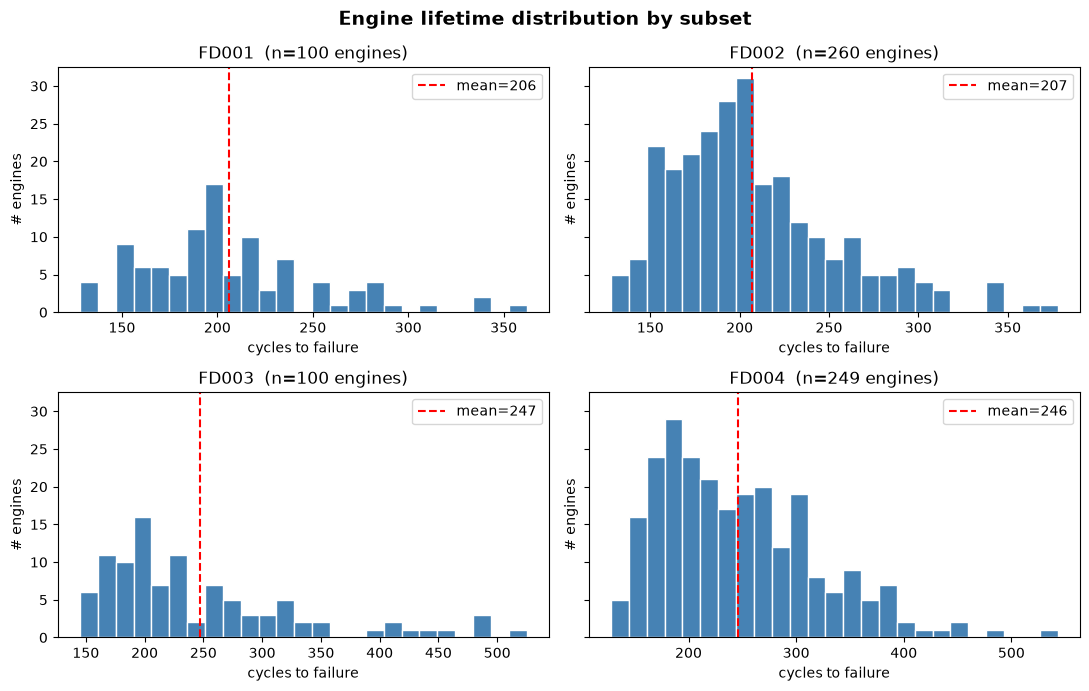

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=True)
for ax, s in zip(axes.flat, SUBSETS):
    lifetimes = train_dfs[s].groupby("unit_id")["cycle"].max()
    ax.hist(lifetimes, bins=25, color="steelblue", edgecolor="white")
    ax.axvline(
        lifetimes.mean(),
        color="red",
        linestyle="--",
        label=f"mean={lifetimes.mean():.0f}",
    )
    ax.set_title(f"{s}  (n={len(lifetimes)} engines)")
    ax.set_xlabel("cycles to failure")
    ax.set_ylabel("# engines")
    ax.legend()
fig.suptitle("Engine lifetime distribution by subset", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_engine_lifetimes.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. Sensor statistics & constant-sensor identification

`describe()` gives the magnitude and spread of each sensor. The variance ranking
then **empirically confirms** the literature-standard "drop these constant sensors"
rule per subset, so we know we are not blindly trusting a citation.

Literature reference (Asif et al., 2022 + community standard):

| Subset(s) | Drop sensors |
| --- | --- |
| FD001, FD003 | 1, 5, 6, 10, 16, 18, 19 |
| FD002, FD004 | 10, 13, 16, 18, 19 |


In [6]:
train_dfs["FD001"][SENSOR_COLS].describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
s_1,20631.0,518.670,0.000,518.670,518.670,518.670,518.670,518.670
s_2,20631.0,642.681,0.500,641.210,642.325,642.640,643.000,644.530
s_3,20631.0,1590.523,6.131,1571.040,1586.260,1590.100,1594.380,1616.910
s_4,20631.0,1408.934,9.001,1382.250,1402.360,1408.040,1414.555,1441.490
s_5,20631.0,14.620,0.000,14.620,14.620,14.620,14.620,14.620
s_6,20631.0,21.610,0.001,21.600,21.610,21.610,21.610,21.610
s_7,20631.0,553.368,0.885,549.850,552.810,553.440,554.010,556.060
s_8,20631.0,2388.097,0.071,2387.900,2388.050,2388.090,2388.140,2388.560
s_9,20631.0,9065.243,22.083,9021.730,9053.100,9060.660,9069.420,9244.590
s_10,20631.0,1.300,0.000,1.300,1.300,1.300,1.300,1.300


In [7]:
LITERATURE_CONSTANTS = {
    "FD001": {1, 5, 6, 10, 16, 18, 19},
    "FD003": {1, 5, 6, 10, 16, 18, 19},
    "FD002": {10, 13, 16, 18, 19},
    "FD004": {10, 13, 16, 18, 19},
}

variance_table = pd.DataFrame(
    {s: train_dfs[s][SENSOR_COLS].std() for s in SUBSETS}
).round(4)

empirical_constants = {
    s: {
        int(c.split("_")[1])
        for c in variance_table.index
        if variance_table.loc[c, s] < 1e-4
    }
    for s in SUBSETS
}

print("Sensor std dev per subset (rows = sensor, cols = subset):")
display(variance_table)

print("\nConstant-sensor cross-check:")
display(
    pd.DataFrame(
        [
            {
                "subset": s,
                "literature_drop": sorted(LITERATURE_CONSTANTS[s]),
                "empirical_drop (std<1e-4)": sorted(empirical_constants[s]),
                "literature ⊆ empirical?": LITERATURE_CONSTANTS[s].issubset(
                    empirical_constants[s]
                ),
            }
            for s in SUBSETS
        ]
    )
)


Sensor std dev per subset (rows = sensor, cols = subset):


,FD001,FD002,FD003,FD004
s_1,0.0000,26.3897,0.0000,26.4368
s_2,0.5001,37.2894,0.5230,37.3426
s_3,6.1311,105.9463,6.8104,106.1676
s_4,9.0006,119.1234,9.7732,119.3276
s_5,0.0000,3.6138,0.0000,3.6229
s_6,0.0014,5.4318,0.0181,5.4440
s_7,0.8851,146.0053,3.4373,146.8802
s_8,0.0710,145.2098,0.1583,145.3482
s_9,22.0829,335.8120,19.9803,336.9275
s_10,0.0000,0.1275,0.0035,0.1277



Constant-sensor cross-check:


,subset,literature_drop,empirical_drop (std<1e-4),literature ⊆ empirical?
0,FD001,"[1, 5, 6, 10, 16, 18, 19]","[1, 5, 10, 16, 18, 19]",False
1,FD002,"[10, 13, 16, 18, 19]",[],False
2,FD003,"[1, 5, 6, 10, 16, 18, 19]","[1, 5, 16, 18, 19]",False
3,FD004,"[10, 13, 16, 18, 19]",[],False


## 5. Sensor correlation

Pairwise correlations among the *informative* sensors per subset. Strong red/blue
blocks indicate redundant signals. We compare FD001 (single regime) with FD004
(six regimes, two fault modes) to see how the correlation structure changes.


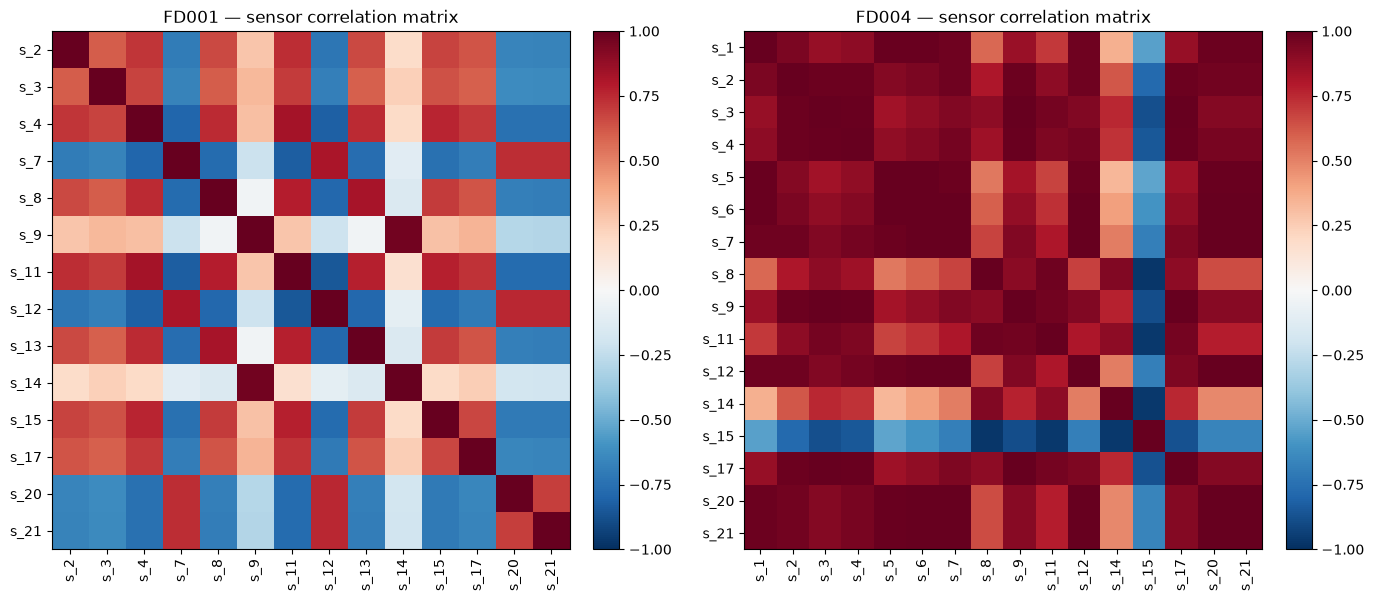

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, s in zip(axes, ["FD001", "FD004"]):
    informative = [
        c for c in SENSOR_COLS if int(c.split("_")[1]) not in LITERATURE_CONSTANTS[s]
    ]
    corr = train_dfs[s][informative].corr()
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(informative)), informative, rotation=90)
    ax.set_yticks(range(len(informative)), informative)
    ax.set_title(f"{s} — sensor correlation matrix")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_sensor_correlation.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Operational regimes

FD001 and FD003 are single-condition (sea level). FD002 and FD004 mix six flight
regimes. We verify this directly by K-means clustering the three operational
settings — clean clusters confirm regime-wise normalization is the right Phase-1
strategy for FD002/FD004.


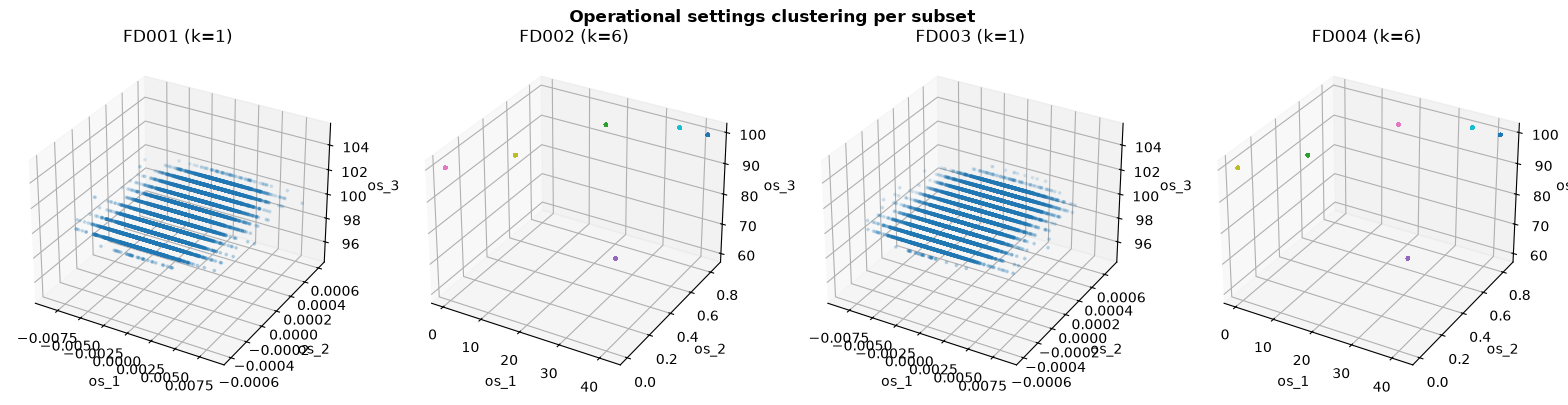

,n_unique_op_rows,n_clusters_assumed
FD001,1423,1
FD002,9824,6
FD003,1479,1
FD004,10232,6


In [9]:
regime_summary = {}
fig, axes = plt.subplots(1, 4, figsize=(16, 4), subplot_kw={"projection": "3d"})
for ax, s in zip(axes, SUBSETS):
    df = train_dfs[s][OP_COLS]
    n_clusters = 6 if s in ("FD002", "FD004") else 1
    if n_clusters > 1:
        km = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit(df.values)
        labels = km.labels_
    else:
        labels = np.zeros(len(df), dtype=int)
    ax.scatter(
        df["os_1"], df["os_2"], df["os_3"],
        c=labels, cmap="tab10", s=3, alpha=0.5,
    )
    ax.set_xlabel("os_1"); ax.set_ylabel("os_2"); ax.set_zlabel("os_3")
    ax.set_title(f"{s} (k={n_clusters})")
    regime_summary[s] = {
        "n_unique_op_rows": len(df.drop_duplicates()),
        "n_clusters_assumed": n_clusters,
    }
fig.suptitle("Operational settings clustering per subset", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_operational_regimes.png", dpi=120, bbox_inches="tight")
plt.show()
pd.DataFrame(regime_summary).T


## 7. Sensor degradation over engine lifetime

For one mid-life engine in each subset, plot how six high-variance sensors evolve.
Each sensor is min-max scaled so they fit on one axis — only the **shape** matters.
This is the visual proof that the degradation signal exists and is learnable.


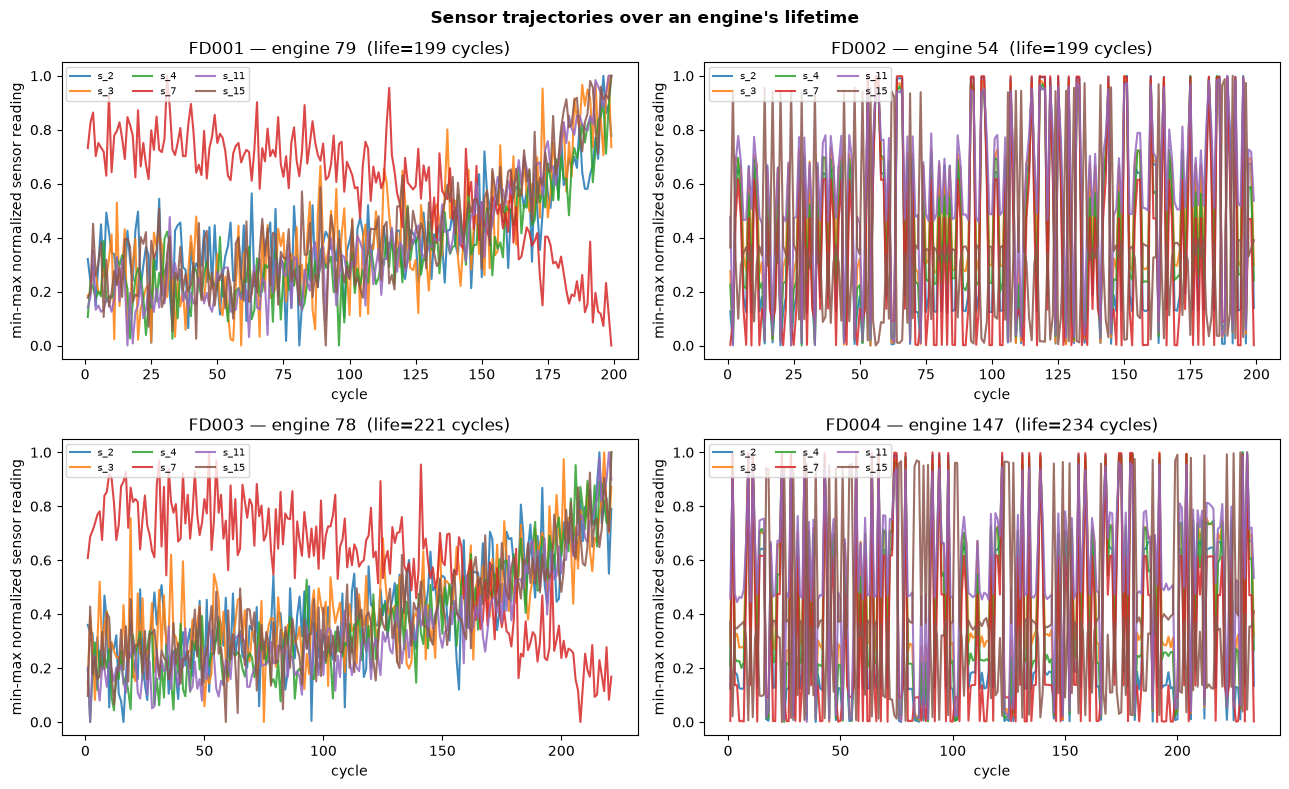

In [10]:
PLOT_SENSORS = ["s_2", "s_3", "s_4", "s_7", "s_11", "s_15"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, s in zip(axes.flat, SUBSETS):
    df = train_dfs[s]
    lifetimes = df.groupby("unit_id")["cycle"].max()
    median_engine = lifetimes.sort_values().index[len(lifetimes) // 2]
    sub = df[df["unit_id"] == median_engine]
    for col in PLOT_SENSORS:
        rng = sub[col].max() - sub[col].min()
        x = (sub[col] - sub[col].min()) / (rng if rng > 0 else 1.0)
        ax.plot(sub["cycle"], x, label=col, alpha=0.85)
    ax.set_title(
        f"{s} — engine {median_engine}  (life={lifetimes[median_engine]} cycles)"
    )
    ax.set_xlabel("cycle")
    ax.set_ylabel("min-max normalized sensor reading")
    ax.legend(fontsize=7, ncol=3, loc="upper left")
fig.suptitle("Sensor trajectories over an engine's lifetime", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_sensor_trajectories.png", dpi=120, bbox_inches="tight")
plt.show()


## 8. RUL target — raw vs piecewise cap

The RUL label for a training row is `max_cycle_of_engine - current_cycle`. Early in
life this can be very large (>300), but the sensors show almost no degradation yet.
The community-standard fix is a **piecewise-linear cap at 125 cycles**: RUL is held
flat at 125 until the engine has fewer than 125 cycles left, then decreases
linearly to 0 at failure. This focuses the regression loss on the informative tail.


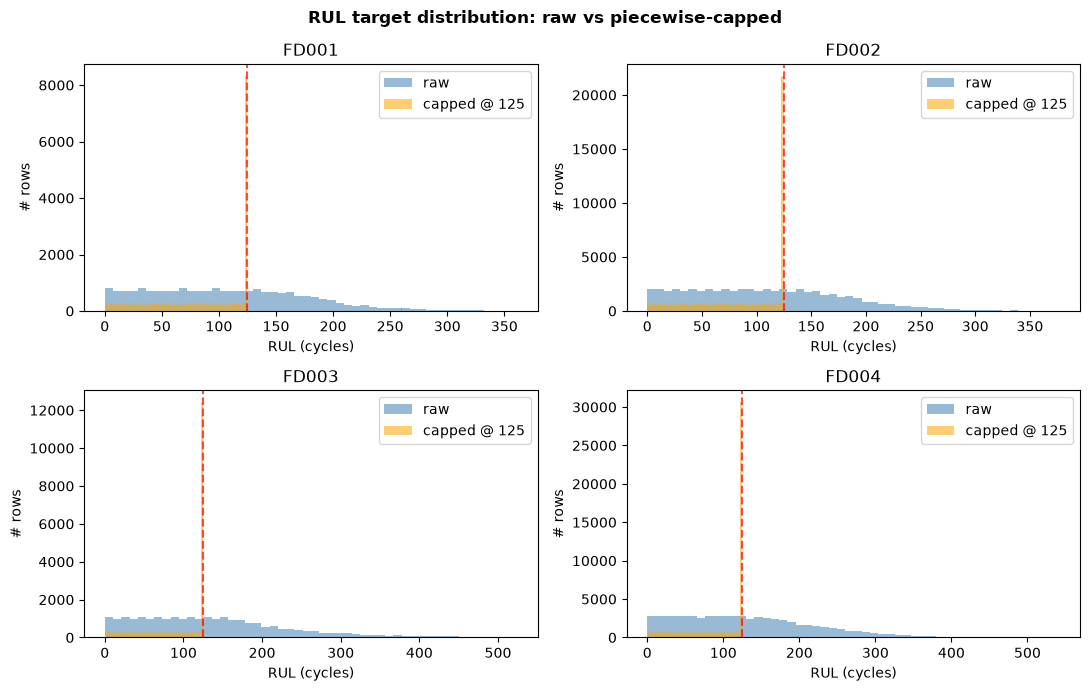

In [11]:
RUL_CAP = 125


def add_rul(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["RUL_raw"] = df.groupby("unit_id")["cycle"].transform("max") - df["cycle"]
    df["RUL_capped"] = df["RUL_raw"].clip(upper=RUL_CAP)
    return df


train_with_rul = {s: add_rul(d) for s, d in train_dfs.items()}

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, s in zip(axes.flat, SUBSETS):
    d = train_with_rul[s]
    ax.hist(d["RUL_raw"], bins=50, alpha=0.55, label="raw", color="steelblue")
    ax.hist(
        d["RUL_capped"], bins=50, alpha=0.55,
        label=f"capped @ {RUL_CAP}", color="orange",
    )
    ax.axvline(RUL_CAP, color="red", linestyle="--", alpha=0.7)
    ax.set_title(s)
    ax.set_xlabel("RUL (cycles)")
    ax.set_ylabel("# rows")
    ax.legend()
fig.suptitle("RUL target distribution: raw vs piecewise-capped", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_rul_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


## 9. Fault label imbalance (RUL ≤ 30)

Our secondary head is a binary "imminent failure" classifier. Positive class =
RUL within 30 cycles. The cross-subset positive rate quantifies the imbalance that
**RQ2** is specifically about — if it varies a lot across subsets, that already
motivates the imbalance-aware aggregation work.


,n_samples,n_positive,pos_rate_%,neg:pos_ratio
subset,,,,
FD001,20631,3100,15.03,5.7
FD002,53759,8060,14.99,5.7
FD003,24720,3100,12.54,7.0
FD004,61249,7719,12.60,6.9


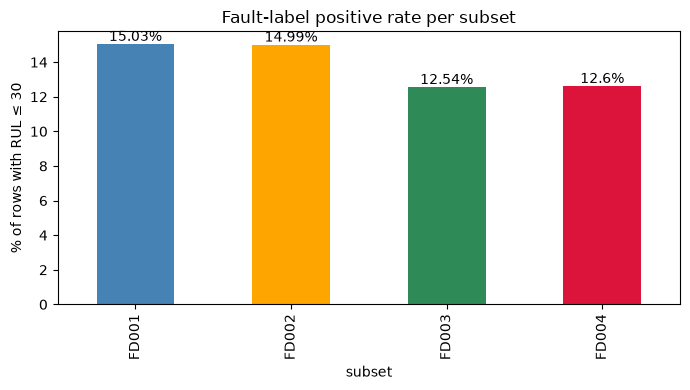

In [12]:
FAULT_THRESHOLD = 30

rows = []
for s, d in train_with_rul.items():
    fault = (d["RUL_raw"] <= FAULT_THRESHOLD).astype(int)
    pos = float(fault.mean())
    rows.append(
        {
            "subset": s,
            "n_samples": len(fault),
            "n_positive": int(fault.sum()),
            "pos_rate_%": round(100 * pos, 2),
            "neg:pos_ratio": round((1 - pos) / max(pos, 1e-9), 1),
        }
    )
balance_df = pd.DataFrame(rows).set_index("subset")
display(balance_df)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["steelblue", "orange", "seagreen", "crimson"]
balance_df["pos_rate_%"].plot(kind="bar", ax=ax, color=colors)
ax.set_ylabel(f"% of rows with RUL ≤ {FAULT_THRESHOLD}")
ax.set_title("Fault-label positive rate per subset")
for i, v in enumerate(balance_df["pos_rate_%"]):
    ax.text(i, v + 0.2, f"{v}%", ha="center")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_fault_imbalance.png", dpi=120, bbox_inches="tight")
plt.show()


## 10. Findings → modeling decisions for Phase 1

Numbers below are read directly from this notebook's outputs.

| Observation | Phase-1 decision |
| --- | --- |
| All 4 subsets share the same 26-column schema with **zero NaNs**; 709 training engines / ~160k rows in total. | One unified loader is enough; no missing-value imputation. |
| Min engine life is **128 cycles** (FD001/FD002/FD004) and 145 (FD003); means cluster around 206 (FD001/FD002) and 246 (FD003/FD004). | Window length 30 with stride 1 fits even the shortest engine; ~98 windows per minimum-life engine. |
| For FD001/FD003 a global std<1e-4 threshold catches 6 of the 7 literature-constant sensors — sensor 6 is *near*-constant (std≈0.001–0.02) rather than literally constant, so we accept the literature drop list `{1,5,6,10,16,18,19}` as-is. | Drop those 7 sensors → 14 informative inputs for FD001/FD003. |
| For FD002/FD004 **no sensor** is globally constant — regime variation dominates the global std. The literature drop list `{10,13,16,18,19}` is derived from *per-regime* variance, so we cannot validate it from a global std view alone. | In Phase 1, do regime-wise z-score normalization **first**, then re-run the variance check inside each of the 6 KMeans regimes; trust the literature list as the working default. |
| FD001/FD003 op-settings collapse to a single regime (1423 / 1479 unique noisy rows); FD002/FD004 each have ≈10k unique op-rows that cleanly split into 6 KMeans clusters. | Confirms the standard 1-regime vs 6-regime preprocessing split. |
| Raw RUL is dominated by an uninformative flat tail above ~150 cycles; capping at 125 yields the canonical hockey-stick distribution. | Apply piecewise-linear cap at 125. |
| Fault positive rate (RUL ≤ 30) is **15.03% / 14.99% / 12.54% / 12.60%** for FD001/FD002/FD003/FD004 — moderately imbalanced (≈1:6) and remarkably uniform globally. | Use `pos_weight` / focal loss to address the 1:6 ratio. The uniformity hides what matters: once we partition into 4 simulated airlines, per-client rates will diverge — that divergence is the **RQ2 hook**. |
| Sample sensor trajectories show clear monotonic drift in the final ~50–80 cycles. | Confirms the model has signal to learn — green-lights Phase 2. |


## 11. Export structured metrics for the React frontend

Every phase in this project writes a `results/<NN_phase>/metrics.json` file. The
React frontend (under `frontend/`, built later) consumes the aggregated
`results/summary.json` produced by `scripts/build_results_summary.py`. The cell
below collects all the EDA's empirical numbers — schema-matched to
`fl_aircraft.utils.PhaseMetrics` — and writes them out.


In [13]:
import sys

REPO_SRC = REPO_ROOT / "src"
if str(REPO_SRC) not in sys.path:
    sys.path.insert(0, str(REPO_SRC))

from fl_aircraft.utils import PhaseMetrics, dump_phase_metrics  # noqa: E402

# Re-derive the numbers we want to expose to the frontend from the notebook state.
per_subset_payload: dict[str, dict] = {}
for s in SUBSETS:
    tr = train_dfs[s]
    te = test_dfs[s]
    rul_df = rul_dfs[s]
    lifetimes = tr.groupby("unit_id")["cycle"].max()
    labeled = train_with_rul[s]
    fault_rate = float((labeled["RUL_raw"] <= FAULT_THRESHOLD).mean())
    per_subset_payload[s] = {
        "train_engines": int(tr["unit_id"].nunique()),
        "test_engines": int(te["unit_id"].nunique()),
        "train_rows": int(len(tr)),
        "test_rows": int(len(te)),
        "min_engine_lifetime": int(lifetimes.min()),
        "mean_engine_lifetime": round(float(lifetimes.mean()), 1),
        "max_engine_lifetime": int(lifetimes.max()),
        "ground_truth_test_rul_count": int(len(rul_df)),
        "n_unique_op_setting_rows": int(len(tr[OP_COLS].drop_duplicates())),
        "n_assumed_op_regimes": 6 if s in ("FD002", "FD004") else 1,
        "n_literature_constant_sensors": len(LITERATURE_CONSTANTS[s]),
        "literature_constant_sensors": sorted(LITERATURE_CONSTANTS[s]),
        "n_empirical_constant_sensors_global_std": len(empirical_constants[s]),
        "empirical_constant_sensors_global_std": sorted(empirical_constants[s]),
        "n_informative_sensors": 21 - len(LITERATURE_CONSTANTS[s]),
        "fault_positive_rate_global": round(fault_rate, 4),
    }

interpretation = (
    "C-MAPSS is structurally clean: 4 subsets, 709 training engines, "
    "~160k rows, zero NaNs. FD001/FD003 are single-regime; FD002/FD004 mix 6 "
    "regimes. The literature 'drop 7 constant sensors' rule for FD001/FD003 "
    "matches 6 of 7 globally (sensor 6 is near-constant). The same rule for "
    "FD002/FD004 cannot be globally validated because regime variation dominates "
    "the global std — per-regime validation is deferred to Phase 2+. Engine "
    "lifetimes span 128–543 cycles; the 30-cycle sliding window is comfortably "
    "safe. Global fault positive rate (RUL ≤ 30) is uniform at 12.5–15.0% "
    "across subsets; per-client heterogeneity is engineered in P1 / P6 / RQ2."
)

metrics_payload = PhaseMetrics(
    phase_id=PHASE_ID,
    phase_name="Phase 0 — Exploratory data analysis",
    interpretation=interpretation,
    subset=None,
    config={
        "subsets": SUBSETS,
        "rul_cap": RUL_CAP,
        "fault_threshold": FAULT_THRESHOLD,
    },
    summary={
        "total_train_engines": int(sum(tr["unit_id"].nunique() for tr in train_dfs.values())),
        "total_train_rows": int(sum(len(tr) for tr in train_dfs.values())),
        "total_test_engines": int(sum(te["unit_id"].nunique() for te in test_dfs.values())),
        "total_test_rows": int(sum(len(te) for te in test_dfs.values())),
        "any_nans_in_data": int(sum(
            tr.isna().sum().sum() + te.isna().sum().sum()
            for tr, te in zip(train_dfs.values(), test_dfs.values())
        )),
        "min_engine_lifetime_global": int(
            min(tr.groupby("unit_id")["cycle"].max().min() for tr in train_dfs.values())
        ),
    },
    per_subset=per_subset_payload,
    artifacts={
        "engine_lifetimes_png": f"results/{PHASE_ID}/01_engine_lifetimes.png",
        "sensor_correlation_png": f"results/{PHASE_ID}/02_sensor_correlation.png",
        "operational_regimes_png": f"results/{PHASE_ID}/03_operational_regimes.png",
        "sensor_trajectories_png": f"results/{PHASE_ID}/04_sensor_trajectories.png",
        "rul_distribution_png": f"results/{PHASE_ID}/05_rul_distribution.png",
        "fault_imbalance_png": f"results/{PHASE_ID}/06_fault_imbalance.png",
        "notebook": "notebooks/01_eda_cmapss.ipynb",
    },
)
out_path = dump_phase_metrics(metrics_payload, FIG_DIR)
print(f"Wrote {out_path}")


Wrote C:\Program Files\Project\AirCraft\FL-for-Aircraft\results\00_eda\metrics.json
